## Imports

In [8]:
from snowflake.snowpark.session import Session
from snowflake.snowpark.functions import col, to_date, to_char, lit



from neuralforecast.losses.pytorch import GMM, MQLoss, DistributionLoss, MAE, PMM, HuberLoss, TukeyLoss, HuberQLoss, HuberMQLoss, MultiOutputMAE
from neuralforecast.core import NeuralForecast
from utilsforecast.plotting import plot_series
from neuralforecast.models import BiTCN, DeepAR,TSMixerx, TiDE, MLP, TFT, RNN, TCN, MLPMultivariate, NBEATSx, DeepNPTS, NHITS, BiTCN,LSTM, DilatedRNN, KAN, GRU, PatchTST
from neuralforecast.tsdataset  import TimeSeriesDataset

import pandas as pd
import numpy as np
import logging
import json
from nbdev.showdoc import show_doc

import plotly.express as px
import plotly.io as pio
import os  

pio.renderers.default = "browser"

## Conexión

In [9]:
with open("config.json", "r") as file:
    connection_parameters = json.load(file)

In [10]:
sess = Session.builder.configs( connection_parameters ).create()

c:\Users\julian.quintero\WORKSPACE\NEURAL_FORECAST\neuralforecast\.venv\Lib\site-packages\snowflake\connector\config_manager.py:351: UserWarning:

Bad owner or permissions on C:\Users\julian.quintero\.snowflake\connections.toml



Initiating login request with your identity provider. A browser window should have opened for you to complete the login. If you can't see it, check existing browser windows, or your OS settings. Press CTRL+C to abort and try again...
Going to open: https://identity-services.elcorteingles.es:443/samlsso?SAMLRequest=pZJfb9owFMW%2FSuQ9x%2FlDSjuLULEytki0jSCs1d5CcqEWjh18HQL79HMISN1D%2BzIpD4lzrn%2Fn3nNH98dKOAfQyJWMSUB94oAsVMnlNiarbObeEQdNLstcKAkxOQGS%2B%2FEI80rUbNKYN7mAfQNoHHuRRNb9iEmjJVM5cmQyrwCZKdhy8jhnIfVZjgjaWBy5lJTILevNmJp5Xtu2tB1Qpbde6Pu%2B53%2F1rKqTfCHvEPXnjForowolriVH29MHiMDzow5hFZaQXgq%2FcdmP4DPKuhch%2B5llqZs%2BLzPiTK7dPSiJTQV6CfrAC1gt5r0BtA7Wx9soCga0tXNzodGqBlprfsgNCC53FKVqNyLfQaGqujGWQe2bt4HSE2rL7eSSaUzqHS9Xs%2FlL%2BuPPQkXJ3Xz5nJXfQ%2FMk93x9fNn71XzzOkxeh1n1GGJUEOfXNeewyzlBbCCRXbrGHvnhjeuHbuBnQcDsE93S4eDmN3Gm1iWXuTlXXlvgJUjDzcnFvj%2BkIAqlDVizovtCFkUDr8sKUZF%2BY9gZqcf%2FN4eR9%2F6uyyo%2B2XSSaaoEL07OTOkqNx%2BHF9DgfMJLd3OWMqhyLiZlqQHRhiiEah80WB8xMboB4o176r87P%2F4L&RelayState=ver%3A1-hi

## Data Preparation

In [9]:
features = '''
CAA_UAT.STG_FCDP.TEMP_TB_FEATURES_JAQB_TotD
CAA_UAT.STG_FCDP.TEMP_TB_FEATURES_JAQB_TotM
CAA_UAT.STG_FCDP.TEMP_TB_FEATURES_JAQB_PrepCsFTDaNoPrime
CAA_UAT.STG_FCDP.TEMP_TB_FEATURES_JAQB_LibeCsT
CAA_UAT.STG_FCDP.TEMP_TB_FEATURES_JAQB_PrepCcDC
CAA_UAT.STG_FCDP.TEMP_TB_FEATURES_JAQB_RecoCcFC

ML_FORECAST_POC.DATA.TONI_EMB_PROMOS
ML_FORECAST_POC.DATA.TONI_EMB_PROMOS_DIM10
'''

In [11]:
problem = 'Prime' # Prime, LibeCsT, PrepCsFTDaNoPrime, TotD, PrepCcDC

In [12]:
if problem == 'Prime':
    df = pd.read_csv('01_FEATURES_PRIME.csv')
    df['DT_FECHA'] = pd.to_datetime(df['DT_FECHA'])
    df = df.drop(['CO_TIPO_FECHA', 'CO_TIPO_METODO_ENVIO','IS_PRIMERITI','DS_DIVISION_AUM'], axis=1)

    df = df.rename(columns={'DT_FECHA': 'ds',    'CO_DIVISION_AUM': 'unique_id',    'QT_UNIDADES': 'y'})

    exogenous_vars = [
        'PC_DESCUENTO_A_PUBLICAR', 'PC_DESCUENTO_APLICADO', 'VL_POTENCIAL_ESTIMADO', 
        'VL_FORECAST', 'QT_REFS_ESTIMADAS', 'QT_REFS_NUEVAS_ESTIMADAS', 
        'QT_UDS_STOCK_ESTIMADO', 'RATIO_FORE_POTE', 'INTENSIDAD', 'STOCK_DESCUENTO',
        'REFS_DESCUENTO', 'RATIO_STOCK_REFS', 'QT_FORE_DIARIO', 'VL_FORE_DIARIO',
        'STOCK_RELATIVO', 'NRO_ACCIONES', 'QT_FORECAST_desc'
    ]

    df['month'] = df['ds'].dt.month
    df["day_of_week"] = df["ds"].dt.dayofweek + 1  # 1: Lunes, 7: Domingo
    df["day_sin"] = np.sin(2 * np.pi * df["day_of_week"] / 7)
    df["day_cos"] = np.cos(2 * np.pi * df["day_of_week"] / 7)

    # exogenous_vars += ['month', 'year','day', 'day_of_week' , 'day_of_year']
    exogenous_vars += ['month','day_of_week', 'day_sin', 'day_cos']
    
    df_model = df[['unique_id', 'ds', 'y'] + exogenous_vars].sort_values(by=['unique_id', 'ds']).copy()

    df_model = df_model[['unique_id', 'ds', 'y'] + exogenous_vars]
    df_model = df_model.sort_values(by=['unique_id','ds'])
    df_model = df_model[df_model['unique_id'] != 'PRIME_NOCAT']

    dummies = pd.get_dummies(df['unique_id'], prefix='CAT')
    df_with_dummies = pd.concat([df_model[['unique_id']], dummies], axis=1)
    static_df  = df_with_dummies.groupby('unique_id').max().reset_index()
    stat_exog_list = static_df.columns[1:].to_list()
else:
    df_problem = sess.sql( f'''SELECT *  FROM CAA_UAT.STG_FCDP.TEMP_TB_FEATURES_JAQB_{problem}''' ).to_pandas()
    
    with open('variables.json', 'r') as f:
        variables = json.load(f)

    if problem == 'LibeCsT':
        i_cs = variables['i_cs_LibeCsT']
    elif problem == 'PrepCsFTDaNoPrime':
        i_cs = variables['i_cs_PrepCsFTDaNoPrime']
    else:
        i_cs = variables['i_cs']


    df = df_problem.copy()
    vars_keys = ['KEY_DS','CO_TIPO_METODO_ENVIO','KEY','LABEL_N0','LABEL_N1','LABEL_N2','LABEL_N3','LABEL_N4','LABEL_N5','LABEL_N6','LABEL_N7']
    df.rename(columns={'DT_FECHA': 'FECHA'}, inplace=True)

    df['FECHA'] = pd.to_datetime(df['FECHA'])

    df = df[['FECHA', 'LABEL', 'QT_UNIDADES'] + vars_keys + i_cs]

    #df = df[['FECHA', 'LABEL', 'QT_UNIDADES']+ i_cs]
    df['OI_BLACK_FRIDAY_CTE'] = df[['OI_BLACK_FRIDAY_FASE_1_CTE', 'OI_BLACK_FRIDAY_FASE_2_CTE']].sum(axis=1)
    #df['IN_CIERRE'] = df.filter(like='IN_CIERRE_M').sum(axis=1)

    # Eliminar columnas utilizadas en la suma
    cols_to_drop = ['OI_BLACK_FRIDAY_FASE_1_CTE', 'OI_BLACK_FRIDAY_FASE_2_CTE']
    cols_to_drop += df.filter(like='DT_WD').columns.tolist()
    cols_to_drop += df.filter(like='DT_M').columns.tolist()
    #cols_to_drop += df.filter(like='IN_CIERRE_M').columns.tolist()
    #cols_to_drop += df.filter(like='_IX').columns.tolist()
    #cols_to_drop += df.filter(like='_IX2').columns.tolist()
    #cols_to_drop += df.filter(like='_INI').columns.tolist()
    #cols_to_drop += df.filter(like='_FIN').columns.tolist()
    df.drop(columns=cols_to_drop, inplace=True)


    
    df["day_of_week"] = df["FECHA"].dt.dayofweek + 1  # 1: Lunes, 7: Domingo
    df["day_sin"] = np.sin(2 * np.pi * df["day_of_week"] / 7)
    df["day_cos"] = np.cos(2 * np.pi * df["day_of_week"] / 7)

    df['month'] = df['FECHA'].dt.month
    df["month_sin"] = np.sin(2 * np.pi * df["day_of_week"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["day_of_week"] / 12)

    exogenous_vars = [col for col in df.columns if col not in ['FECHA', 'LABEL', 'QT_UNIDADES'] + vars_keys]

    df_model = df[['LABEL', 'FECHA', 'QT_UNIDADES'] + exogenous_vars].sort_values(by=['LABEL', 'FECHA']).copy()

    df_model.rename(columns={'FECHA': 'ds', 'LABEL': 'unique_id', 'QT_UNIDADES': 'y'}, inplace=True)

    dummies = pd.get_dummies(df_model['unique_id'], prefix='CAT')
    df_with_dummies = pd.concat([df_model[['unique_id']], dummies], axis=1)
    static_df  = df_with_dummies.groupby('unique_id').max().reset_index()
    stat_exog_list = static_df.columns[1:].to_list()

print(df_model.sort_values(by=['unique_id','ds']).head().to_string())
print(df_model.sort_values(by=['unique_id','ds']).tail().to_string())

             unique_id         ds    y  PC_DESCUENTO_A_PUBLICAR  PC_DESCUENTO_APLICADO  VL_POTENCIAL_ESTIMADO  VL_FORECAST  QT_REFS_ESTIMADAS  QT_REFS_NUEVAS_ESTIMADAS  QT_UDS_STOCK_ESTIMADO  RATIO_FORE_POTE  INTENSIDAD  STOCK_DESCUENTO  REFS_DESCUENTO  RATIO_STOCK_REFS  QT_FORE_DIARIO  VL_FORE_DIARIO  STOCK_RELATIVO  NRO_ACCIONES  QT_FORECAST_desc  month  day_of_week       day_sin   day_cos
5   PRIME_COMPLEMENTOS 2022-04-01  133                     0.00                   0.00                      0            0                  0                         0                      0         0.000000    0.000000             0.00            0.00          0.000000        0.000000        0.000000             0.0             0          0.000000      4            5 -9.749279e-01 -0.222521
15  PRIME_COMPLEMENTOS 2022-04-02   96                     0.00                   0.00                      0            0                  0                         0                      0         0.000000   

In [121]:
# print(df[(df['ds'] >= '2024-11-20') & (df['ds'] <= '2024-12-03') & (df['unique_id'] == 'ENVIOS')][['ds', 'unique_id', 'OI_BLACK_FRIDAY_CTE']].sort_values(by='ds').to_string())

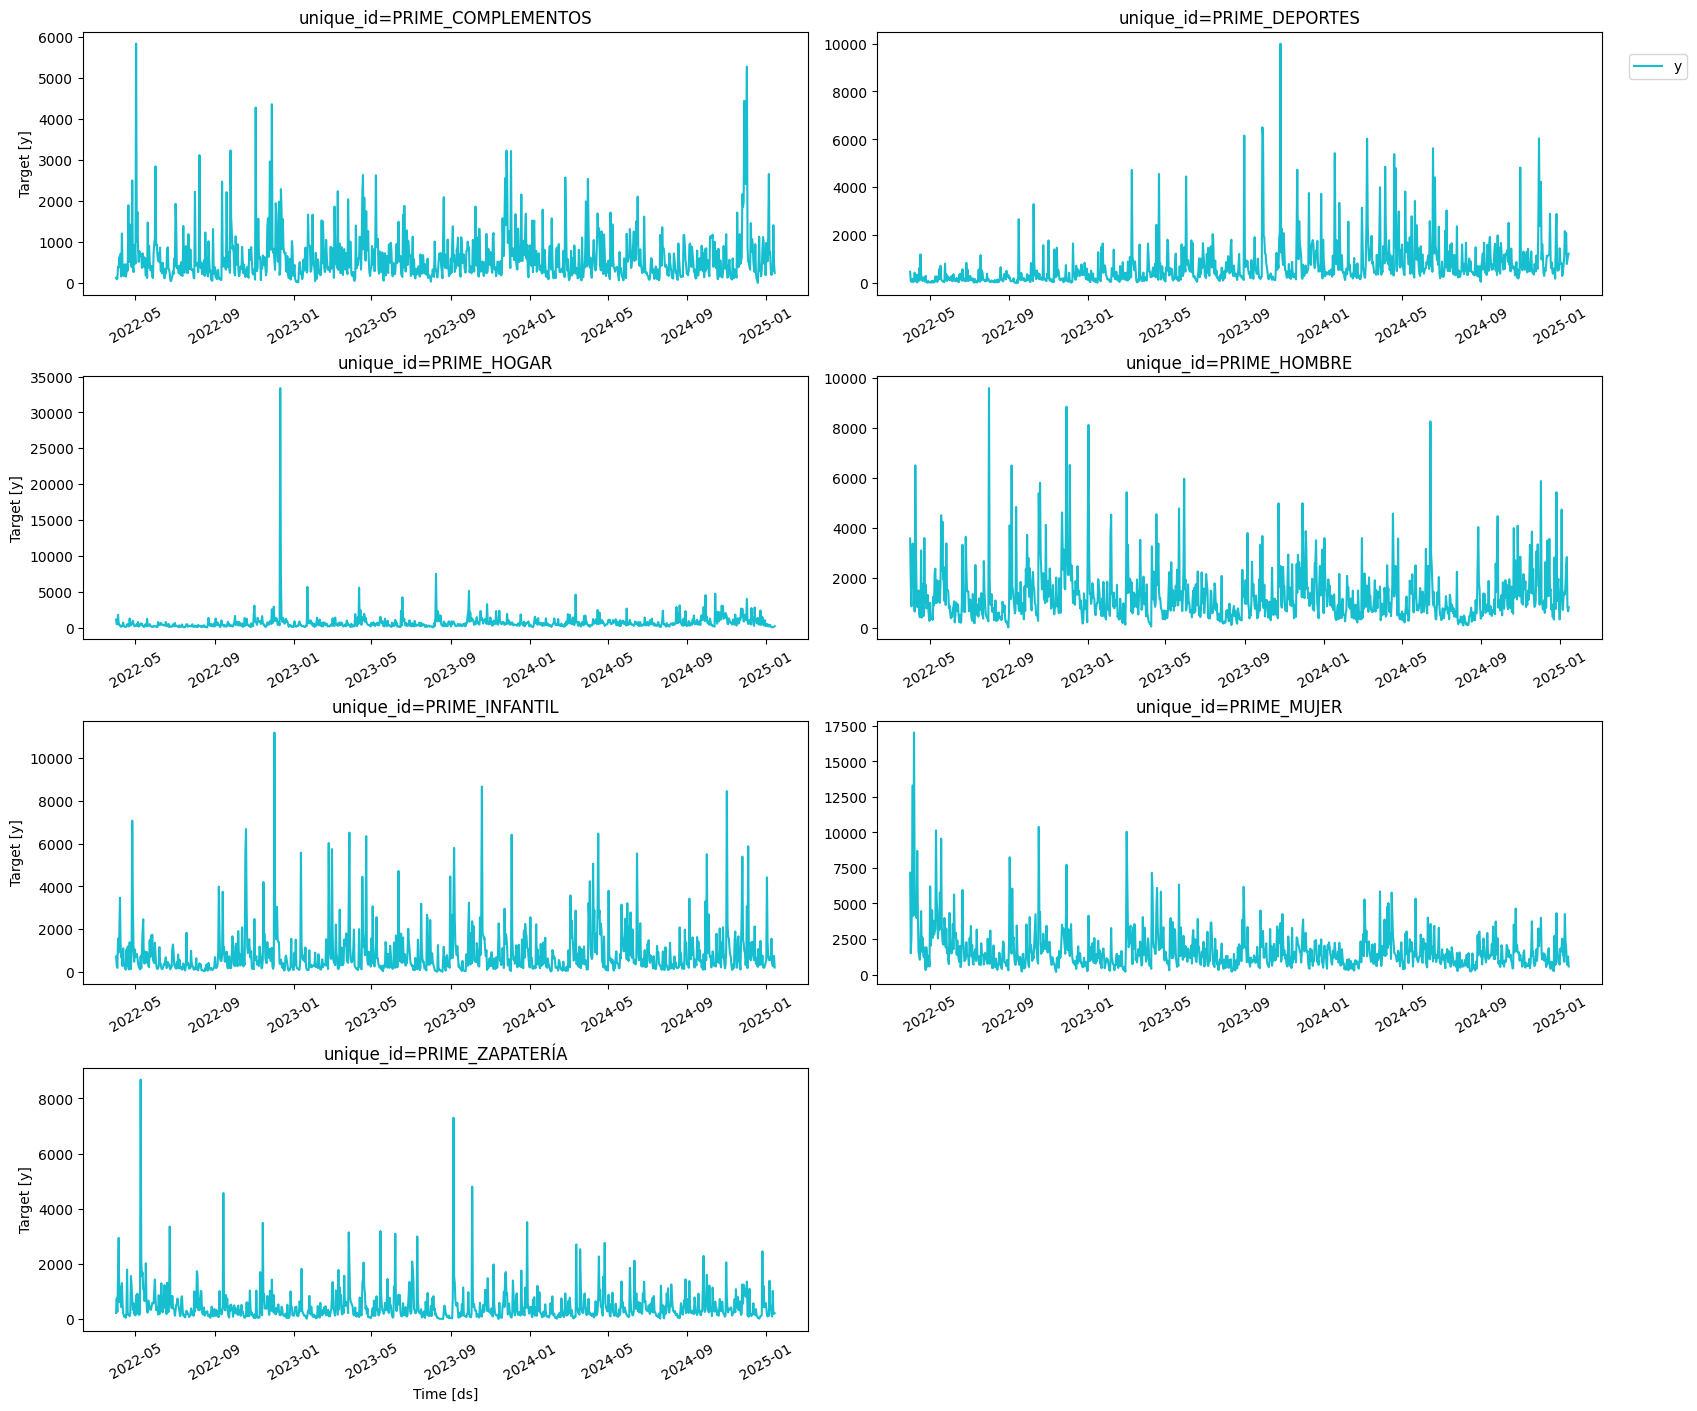

In [13]:
plot_series(df_model)

## Def Model

In [6]:
from typing import Optional

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np

from neuralforecast.losses.pytorch import MAE
from neuralforecast.common._base_windows import BaseWindows

In [8]:
class CustomConv1d(nn.Module):
    """
    Forward- and backward looking Conv1D
    """
    def __init__(self, in_channels, out_channels, kernel_size, padding=0, dilation=1, mode='backward', groups=1):
        super().__init__()
        k = np.sqrt(1 / (in_channels * kernel_size))
        weight_data = -k + 2 * k * torch.rand((out_channels, in_channels // groups, kernel_size))
        bias_data = -k + 2 * k * torch.rand((out_channels))
        self.weight = nn.Parameter(weight_data, requires_grad=True)
        self.bias = nn.Parameter(bias_data, requires_grad=True)  
        self.dilation = dilation
        self.groups = groups
        if mode == 'backward':
            self.padding_left = padding
            self.padding_right= 0
        elif mode == 'forward':
            self.padding_left = 0
            self.padding_right= padding            

    def forward(self, x):
        xp = F.pad(x, (self.padding_left, self.padding_right))
        return F.conv1d(xp, self.weight, self.bias, dilation=self.dilation, groups=self.groups)

class TCNCell(nn.Module):
    """
    Temporal Convolutional Network Cell, consisting of CustomConv1D modules.
    """    
    def __init__(self, in_channels, out_channels, kernel_size, padding, dilation, mode, groups, dropout):
        super().__init__()
        self.conv1 = CustomConv1d(in_channels, out_channels, kernel_size, padding, dilation, mode, groups)
        self.conv2 = CustomConv1d(out_channels, in_channels * 2, 1)
        self.drop = nn.Dropout(dropout)
        
    def forward(self, x):
        h_prev, out_prev = x
        h = self.drop(F.gelu(self.conv1(h_prev)))
        h_next, out_next = self.conv2(h).chunk(2, 1)
        return (h_prev + h_next, out_prev + out_next)

In [9]:
class BiTCN(BaseWindows):
    """ BiTCN

    Bidirectional Temporal Convolutional Network (BiTCN) is a forecasting architecture based on two temporal convolutional networks (TCNs). The first network ('forward') encodes future covariates of the time series, whereas the second network ('backward') encodes past observations and covariates. This is a univariate model.

    **Parameters:**<br>
    `h`: int, forecast horizon.<br>
    `input_size`: int, considered autorregresive inputs (lags), y=[1,2,3,4] input_size=2 -> lags=[1,2].<br>
    `hidden_size`: int=16, units for the TCN's hidden state size.<br>
    `dropout`: float=0.1, dropout rate used for the dropout layers throughout the architecture.<br>
    `futr_exog_list`: str list, future exogenous columns.<br>
    `hist_exog_list`: str list, historic exogenous columns.<br>
    `stat_exog_list`: str list, static exogenous columns.<br>
    `exclude_insample_y`: bool=False, the model skips the autoregressive features y[t-input_size:t] if True.<br>
    `loss`: PyTorch module, instantiated train loss class from [losses collection](https://nixtla.github.io/neuralforecast/losses.pytorch.html).<br>
    `valid_loss`: PyTorch module=`loss`, instantiated valid loss class from [losses collection](https://nixtla.github.io/neuralforecast/losses.pytorch.html).<br>
    `max_steps`: int=1000, maximum number of training steps.<br>
    `learning_rate`: float=1e-3, Learning rate between (0, 1).<br>
    `num_lr_decays`: int=-1, Number of learning rate decays, evenly distributed across max_steps.<br>
    `early_stop_patience_steps`: int=-1, Number of validation iterations before early stopping.<br>
    `val_check_steps`: int=100, Number of training steps between every validation loss check.<br>
    `batch_size`: int=32, number of different series in each batch.<br>
    `valid_batch_size`: int=None, number of different series in each validation and test batch, if None uses batch_size.<br>
    `windows_batch_size`: int=1024, number of windows to sample in each training batch, default uses all.<br>
    `inference_windows_batch_size`: int=-1, number of windows to sample in each inference batch, -1 uses all.<br>
    `start_padding_enabled`: bool=False, if True, the model will pad the time series with zeros at the beginning, by input size.<br>
    `step_size`: int=1, step size between each window of temporal data.<br>
    `scaler_type`: str='identity', type of scaler for temporal inputs normalization see [temporal scalers](https://nixtla.github.io/neuralforecast/common.scalers.html).<br>
    `random_seed`: int=1, random_seed for pytorch initializer and numpy generators.<br>
    `drop_last_loader`: bool=False, if True `TimeSeriesDataLoader` drops last non-full batch.<br>
    `alias`: str, optional,  Custom name of the model.<br>
    `optimizer`: Subclass of 'torch.optim.Optimizer', optional, user specified optimizer instead of the default choice (Adam).<br>
    `optimizer_kwargs`: dict, optional, list of parameters used by the user specified `optimizer`.<br>
    `lr_scheduler`: Subclass of 'torch.optim.lr_scheduler.LRScheduler', optional, user specified lr_scheduler instead of the default choice (StepLR).<br>
    `lr_scheduler_kwargs`: dict, optional, list of parameters used by the user specified `lr_scheduler`.<br>
    `dataloader_kwargs`: dict, optional, list of parameters passed into the PyTorch Lightning dataloader by the `TimeSeriesDataLoader`. <br>
    `**trainer_kwargs`: int,  keyword trainer arguments inherited from [PyTorch Lighning's trainer](https://pytorch-lightning.readthedocs.io/en/stable/api/pytorch_lightning.trainer.trainer.Trainer.html?highlight=trainer).<br>    

    **References**<br>  
    - [Olivier Sprangers, Sebastian Schelter, Maarten de Rijke (2023). Parameter-Efficient Deep Probabilistic Forecasting. International Journal of Forecasting 39, no. 1 (1 January 2023): 332–45. URL: https://doi.org/10.1016/j.ijforecast.2021.11.011.](https://doi.org/10.1016/j.ijforecast.2021.11.011)<br>    

    """
    # Class attributes
    SAMPLING_TYPE = 'windows'
    EXOGENOUS_FUTR = True
    EXOGENOUS_HIST = True
    EXOGENOUS_STAT = True

    def __init__(self,
                 h: int,
                 input_size: int,
                 hidden_size: int = 16,
                 dropout: float = 0.5,
                 futr_exog_list = None,
                 hist_exog_list = None,
                 stat_exog_list = None,
                 exclude_insample_y = False,
                 loss = MAE(),
                 valid_loss = None,
                 max_steps: int = 1000,
                 learning_rate: float = 1e-3,
                 num_lr_decays: int = -1,
                 early_stop_patience_steps: int =-1,
                 val_check_steps: int = 100,
                 batch_size: int = 32,
                 valid_batch_size: Optional[int] = None,
                 windows_batch_size = 1024,
                 inference_windows_batch_size = 1024,
                 start_padding_enabled = False,
                 step_size: int = 1,
                 scaler_type: str = 'identity',
                 random_seed: int = 1,
                 drop_last_loader: bool = False,
                 optimizer = None,
                 optimizer_kwargs = None,
                 lr_scheduler = None,
                 lr_scheduler_kwargs = None,
                 dataloader_kwargs=None,
                 **trainer_kwargs):
        super(BiTCN, self).__init__(
            h=h,
            input_size=input_size,
            futr_exog_list=futr_exog_list,
            hist_exog_list=hist_exog_list,
            stat_exog_list=stat_exog_list,
            exclude_insample_y = exclude_insample_y,
            loss=loss,
            valid_loss=valid_loss,
            max_steps=max_steps,
            learning_rate=learning_rate,
            num_lr_decays=num_lr_decays,
            early_stop_patience_steps=early_stop_patience_steps,
            val_check_steps=val_check_steps,
            batch_size=batch_size,
            valid_batch_size=valid_batch_size,
            windows_batch_size=windows_batch_size,
            inference_windows_batch_size=inference_windows_batch_size,
            start_padding_enabled=start_padding_enabled,
            step_size=step_size,
            scaler_type=scaler_type,
            random_seed=random_seed,
            drop_last_loader=drop_last_loader,
            optimizer=optimizer,
            optimizer_kwargs=optimizer_kwargs,
            lr_scheduler=lr_scheduler,
            lr_scheduler_kwargs=lr_scheduler_kwargs,
            dataloader_kwargs=dataloader_kwargs,
            **trainer_kwargs
        )

        #----------------------------------- Parse dimensions -----------------------------------#
        # TCN
        kernel_size = 2  # Not really necessary as parameter, so simplifying the architecture here.
        self.kernel_size = kernel_size
        self.hidden_size = hidden_size
        self.h = h
        self.input_size = input_size
        self.dropout = dropout
        
        # Calculate required number of TCN layers based on the required receptive field of the TCN
        self.n_layers_bwd = int(np.ceil(np.log2(((self.input_size - 1) / (self.kernel_size - 1)) + 1)))     
       
        #---------------------------------- Instantiate Model -----------------------------------#
        
        # Dense layers
        self.lin_hist = nn.Linear(1 + self.hist_exog_size + self.stat_exog_size + self.futr_exog_size, hidden_size)
        self.drop_hist = nn.Dropout(dropout)
        
        # TCN looking back
        layers_bwd = [TCNCell(
                        hidden_size, 
                        hidden_size, 
                        kernel_size, 
                        padding = (kernel_size-1)*2**i, 
                        dilation = 2**i, 
                        mode = 'backward', 
                        groups = 1, 
                        dropout = dropout) for i in range(self.n_layers_bwd)]      
        self.net_bwd = nn.Sequential(*layers_bwd)
        
        # TCN looking forward when future covariates exist
        output_lin_dim_multiplier = 1
        if self.futr_exog_size > 0:
            self.n_layers_fwd = int(np.ceil(np.log2(((self.h + self.input_size - 1) / (self.kernel_size - 1)) + 1)))
            self.lin_futr = nn.Linear(self.futr_exog_size, hidden_size)
            self.drop_futr = nn.Dropout(dropout)
            layers_fwd = [TCNCell(
                            hidden_size, 
                            hidden_size, 
                            kernel_size, 
                            padding = (kernel_size - 1)*2**i, 
                            dilation = 2**i, 
                            mode = 'forward', 
                            groups = 1, 
                            dropout = dropout) for i in range(self.n_layers_fwd)]             
            self.net_fwd = nn.Sequential(*layers_fwd)
            output_lin_dim_multiplier += 2

        # Dense temporal and output layers
        self.drop_temporal = nn.Dropout(dropout)
        self.temporal_lin1 = nn.Linear(self.input_size, hidden_size)
        self.temporal_lin2 = nn.Linear(hidden_size, self.h)
        self.output_lin = nn.Linear(output_lin_dim_multiplier * hidden_size, self.loss.outputsize_multiplier)

    def forward(self, windows_batch):
        # Parse windows_batch
        x             = windows_batch['insample_y'].unsqueeze(-1)       #   [B, L, 1]
        hist_exog     = windows_batch['hist_exog']                      #   [B, L, X]
        futr_exog     = windows_batch['futr_exog']                      #   [B, L + h, F]
        stat_exog     = windows_batch['stat_exog']                      #   [B, S]

        # Concatenate x with historic exogenous
        batch_size, seq_len = x.shape[:2]                               #   B = batch_size, L = seq_len
        if self.hist_exog_size > 0:
            x = torch.cat((x, hist_exog), dim=2)                        #   [B, L, 1] + [B, L, X] -> [B, L, 1 + X]

        # Concatenate x with static exogenous
        if self.stat_exog_size > 0:
            stat_exog = stat_exog.unsqueeze(1).repeat(1, seq_len, 1)    #   [B, S] -> [B, L, S]
            x = torch.cat((x, stat_exog), dim=2)                        #   [B, L, 1 + X] + [B, L, S] -> [B, L, 1 + X + S]

        # Concatenate x with future exogenous & apply forward TCN to x_futr
        if self.futr_exog_size > 0:
            x = torch.cat((x, futr_exog[:, :seq_len]), dim=2)           #   [B, L, 1 + X + S] + [B, L, F] -> [B, L, 1 + X + S + F]
            x_futr = self.drop_futr(self.lin_futr(futr_exog))           #   [B, L + h, F] -> [B, L + h, hidden_size]
            x_futr = x_futr.permute(0, 2, 1)                            #   [B, L + h, hidden_size] -> [B, hidden_size, L + h]
            _, x_futr = self.net_fwd((x_futr, 0))                       #   [B, hidden_size, L + h] -> [B, hidden_size, L + h]
            x_futr_L = x_futr[:, :, :seq_len]                           #   [B, hidden_size, L + h] -> [B, hidden_size, L]
            x_futr_h = x_futr[:, :, seq_len:]                           #   [B, hidden_size, L + h] -> [B, hidden_size, h]

        # Apply backward TCN to x
        x = self.drop_hist(self.lin_hist(x))                            #   [B, L, 1 + X + S + F] -> [B, L, hidden_size]
        x = x.permute(0, 2, 1)                                          #   [B, L, hidden_size] -> [B, hidden_size, L]
        _, x = self.net_bwd((x, 0))                                     #   [B, hidden_size, L] -> [B, hidden_size, L]

        # Concatenate with future exogenous for seq_len
        if self.futr_exog_size > 0:
            x = torch.cat((x, x_futr_L), dim=1)                         #   [B, hidden_size, L] + [B, hidden_size, L] -> [B, 2 * hidden_size, L]

        # Temporal dense layer to go to output horizon
        x = self.drop_temporal(F.gelu(self.temporal_lin1(x)))           #   [B, 2 * hidden_size, L] -> [B, 2 * hidden_size, hidden_size]
        x = self.temporal_lin2(x)                                       #   [B, 2 * hidden_size, hidden_size] -> [B, 2 * hidden_size, h]
        
        # Concatenate with future exogenous for horizon
        if self.futr_exog_size > 0:
            x = torch.cat((x, x_futr_h), dim=1)                         #   [B, 2 * hidden_size, h] + [B, hidden_size, h] -> [B, 3 * hidden_size, h]

        # Output layer to create forecasts
        x = x.permute(0, 2, 1)                                          #   [B, 3 * hidden_size, h] -> [B, h, 3 * hidden_size]
        x = self.output_lin(x)                                          #   [B, h, 3 * hidden_size] -> [B, h, n_outputs] 

        # Map to output domain
        forecast = self.loss.domain_map(x)
        
        return forecast

## Model

In [14]:
ses_tag = f"Auto_Prime_v1"


horizon = 90
max_steps = 10
val_check_steps= int(max_steps/10)
input_size = 5*horizon
dropout=0.05
learning_rate = 1e-2


train_cutoff = pd.Timestamp('2024-09-29') # '2024-09-30'
# train_cutoff = df['ds'].max() - pd.Timedelta(days=horizon) 
train_data = df_model[df_model['ds'] <= train_cutoff]
test_data = df_model[(df_model['ds'] > train_cutoff) & (df_model['ds'] <= train_cutoff + pd.Timedelta(days=horizon))]


In [9]:
logging.getLogger("pytorch_lightning").setLevel(logging.WARNING)


In [16]:
# from nbdev.showdoc import show_doc
# show_doc(TiDE)
# show_doc(RNN.fit, name='RNN.fit')

### Modelo

In [123]:
models = [  BiTCN(h = horizon,
                input_size = input_size,
                max_steps=max_steps,
                futr_exog_list = exogenous_vars, 
                stat_exog_list = stat_exog_list,
                #hist_exog_list=, 
                scaler_type = 'robust',
                loss=PMM(n_components=5, return_params=False),
                learning_rate = learning_rate,

                hidden_size=16,  
                dropout=dropout,
                random_seed = 123,
                val_check_steps=val_check_steps,                                  
                )              

]

Seed set to 123


### Optimización de hiperparámetros con ray

In [50]:
from ray import tune
from neuralforecast.auto import AutoBiTCN,  AutoNHITS

nhits_config = AutoBiTCN.get_default_config(h = horizon, backend="ray") 

# nhits_config = {
#        "max_steps": 100,                                                         # Number of SGD steps
#       "input_size": 24,                                                         # Size of input window
#       "learning_rate": tune.loguniform(1e-5, 1e-1),                             # Initial Learning rate
#       "n_pool_kernel_size": tune.choice([[2, 2, 2], [16, 8, 1]]),               # MaxPool's Kernelsize
#       "n_freq_downsample": tune.choice([[168, 24, 1], [24, 12, 1], [1, 1, 1]]), # Interpolation expressivity ratios
#       "val_check_steps": 50,                                                    # Compute validation every 50 steps
#       "random_seed": tune.randint(1, 10),                                       # Random seed
#    }


from ray.tune.search.hyperopt import HyperOptSearch
from neuralforecast.losses.pytorch import MAE
from neuralforecast.auto import AutoBiTCN

models = [AutoBiTCN(h=horizon,
                  loss=PMM(n_components=5, return_params=False),
                  config=nhits_config,
                  search_alg=HyperOptSearch(),
                  backend='ray',
                  num_samples=30)]



### Optimizacion de hiperparámetros con optuna

In [ ]:
import optuna
from neuralforecast.auto import AutoBiTCN,  AutoNHITS, AutoRNN, AutoTCN,AutoDeepAR,AutoDilatedRNN,AutoNBEATSx,AutoTiDE,AutoKAN,AutoPatchTST,AutoTimesNet,AutoHINT,AutoTSMixerx

# optuna.logging.set_verbosity(optuna.logging.WARNING) # Use this to disable training prints from optuna
optuna.logging.set_verbosity(optuna.logging.DEBUG) # Use this to enable training prints from optuna


In [17]:
num_samples = 10
max_steps = 100
bitcn_default_config = AutoBiTCN.get_default_config(h = horizon, backend="optuna") 
nhits_default_config = AutoNHITS.get_default_config(h = horizon, backend="optuna")                   
rnn_default_config = AutoRNN.get_default_config(h = horizon, backend="optuna") 
tcn_default_config = AutoTCN.get_default_config(h = horizon, backend="optuna") 
deepar_default_config = AutoDeepAR.get_default_config(h = horizon, backend="optuna") 
drnn_default_config = AutoDilatedRNN.get_default_config(h = horizon, backend="optuna") 
nbx_default_config = AutoNBEATSx.get_default_config(h = horizon, backend="optuna") 
tide_default_config = AutoTiDE.get_default_config(h = horizon, backend="optuna") 
kan_default_config = AutoKAN.get_default_config(h = horizon, backend="optuna") 
ptst_default_config = AutoPatchTST.get_default_config(h = horizon, backend="optuna") 
timesnet_default_config = AutoTimesNet.get_default_config(h = horizon, backend="optuna") 

def config_nhits(trial,exogenous_vars=exogenous_vars, stat_exog_list=stat_exog_list):
    config = {**nhits_default_config(trial)}
    config.update({
                   "random_seed": trial.suggest_int("random_seed", 1, 10), 
                    "futr_exog_list" : exogenous_vars, 
                    "stat_exog_list" : stat_exog_list,
                    "max_steps": max_steps,
                   })
    return config

                

def config_bitcn(trial,exogenous_vars=exogenous_vars, stat_exog_list=stat_exog_list):
    config = {**bitcn_default_config(trial)}
    config.update({
                   "random_seed": trial.suggest_int("random_seed", 1, 10), 
                    "futr_exog_list" : exogenous_vars, 
                    "stat_exog_list" : stat_exog_list,
                    "max_steps": max_steps,
                   })
    return config


def config_rnn(trial,exogenous_vars=exogenous_vars, stat_exog_list=stat_exog_list):
    config = {**rnn_default_config(trial)}
    config.update({
                   "random_seed": trial.suggest_int("random_seed", 1, 10), 
                    "futr_exog_list" : exogenous_vars, 
                    "stat_exog_list" : stat_exog_list,
                    "max_steps": 4,
                   })
    return config

                

def config_tcn(trial,exogenous_vars=exogenous_vars, stat_exog_list=stat_exog_list):
    config = {**tcn_default_config(trial)}
    config.update({
                   "random_seed": trial.suggest_int("random_seed", 1, 10), 
                    "futr_exog_list" : exogenous_vars, 
                    "stat_exog_list" : stat_exog_list,
                    "max_steps": 4,
                   })
    return config



def config_deepar(trial,exogenous_vars=exogenous_vars, stat_exog_list=stat_exog_list):
    config = {**deepar_default_config(trial)}
    config.update({
                   "random_seed": trial.suggest_int("random_seed", 1, 10), 
                    "futr_exog_list" : exogenous_vars, 
                    "stat_exog_list" : stat_exog_list,
                    "max_steps": 4,
                   })
    return config

                

def config_drnn(trial,exogenous_vars=exogenous_vars, stat_exog_list=stat_exog_list):
    config = {**drnn_default_config(trial)}
    config.update({
                   "random_seed": trial.suggest_int("random_seed", 1, 10), 
                    "futr_exog_list" : exogenous_vars, 
                    "stat_exog_list" : stat_exog_list,
                    "max_steps": 4,
                   })
    return config


def config_nbx(trial,exogenous_vars=exogenous_vars, stat_exog_list=stat_exog_list):
    config = {**nbx_default_config(trial)}
    config.update({
                   "random_seed": trial.suggest_int("random_seed", 1, 10), 
                    "futr_exog_list" : exogenous_vars, 
                    "stat_exog_list" : stat_exog_list,
                    "max_steps": 4,
                   })
    return config

                

def config_tide(trial,exogenous_vars=exogenous_vars, stat_exog_list=stat_exog_list):
    config = {**tide_default_config(trial)}
    config.update({
                   "random_seed": trial.suggest_int("random_seed", 1, 10), 
                    "futr_exog_list" : exogenous_vars, 
                    "stat_exog_list" : stat_exog_list,
                    "max_steps": 4,
                   })
    return config


#
def config_kan(trial,exogenous_vars=exogenous_vars, stat_exog_list=stat_exog_list):
    config = {**kan_default_config(trial)}
    config.update({
                   "random_seed": trial.suggest_int("random_seed", 1, 10), 
                    "futr_exog_list" : exogenous_vars, 
                    "stat_exog_list" : stat_exog_list,
                    "max_steps": 4,
                   })
    return config

                

def config_ptst(trial,exogenous_vars=exogenous_vars, stat_exog_list=stat_exog_list):
    config = {**ptst_default_config(trial)}
    config.update({
                   "random_seed": trial.suggest_int("random_seed", 1, 10), 
                    "futr_exog_list" : exogenous_vars, 
                    "stat_exog_list" : stat_exog_list,
                    "max_steps": 4,
                   })
    return config


def config_timesnet(trial,exogenous_vars=exogenous_vars, stat_exog_list=stat_exog_list):
    config = {**timesnet_default_config(trial)}
    config.update({
                   "random_seed": trial.suggest_int("random_seed", 1, 10), 
                    "futr_exog_list" : exogenous_vars, 
                    "stat_exog_list" : stat_exog_list,
                    "max_steps": 4,
                   })
    return config

                




In [18]:
study = optuna.create_study(
    study_name="my_study",
    storage="sqlite:///example.db",
    direction="minimize",
    load_if_exists=True
)
# optuna-dashboard sqlite:///example.db

[I 2025-02-10 12:14:59,059] Using an existing study with name 'my_study' instead of creating a new one.


In [19]:
models = [AutoBiTCN(h=horizon,
                  loss=PMM(n_components=5, return_params=False),
                  config=config_bitcn,
                  search_alg=optuna.samplers.TPESampler(),
                  backend='optuna',
                  num_samples=num_samples),
            # AutoNHITS(h=horizon,
            #       loss=PMM(n_components=5, return_params=False),
            #       config=config_nhits,
            #       search_alg=optuna.samplers.TPESampler(),
            #       backend='optuna',
            #       num_samples=num_samples),
            # AutoRNN(h=horizon,
            #       loss=PMM(n_components=5, return_params=False),
            #       config=config_rnn,
            #       search_alg=optuna.samplers.TPESampler(),
            #       backend='optuna',
            #       num_samples=num_samples),
            # AutoTCN(h=horizon,
            #       loss=PMM(n_components=5, return_params=False),
            #       config=config_tcn,
            #       search_alg=optuna.samplers.TPESampler(),
            #       backend='optuna',
            #       num_samples=num_samples),

            # AutoDilatedRNN(h=horizon,
            #       loss=PMM(n_components=5, return_params=False),
            #       config=config_drnn,
            #       search_alg=optuna.samplers.TPESampler(),
            #       backend='optuna',
            #       num_samples=num_samples),
            # AutoNBEATSx(h=horizon,
            #       loss=PMM(n_components=5, return_params=False),
            #       config=nbx_default_config,
            #       search_alg=optuna.samplers.TPESampler(),
            #       backend='optuna',
            #       num_samples=num_samples),
            # AutoTiDE(h=horizon,
            #       loss=PMM(n_components=5, return_params=False),
            #       config=tide_default_config,
            #       search_alg=optuna.samplers.TPESampler(),
            #       backend='optuna',
            #       num_samples=num_samples),
            # AutoKAN(h=horizon,
            #       loss=PMM(n_components=5, return_params=False),
            #       config=kan_default_config,
            #       search_alg=optuna.samplers.TPESampler(),
            #       backend='optuna',
            #       num_samples=num_samples),
            # AutoPatchTST(h=horizon,
            #       loss=PMM(n_components=5, return_params=False),
            #       config=ptst_default_config,
            #       search_alg=optuna.samplers.TPESampler(),
            #       backend='optuna',
            #       num_samples=num_samples),
            # AutoTimesNet(h=horizon,
            #       loss=PMM(n_components=5, return_params=False),
            #       config=timesnet_default_config,
            #       search_alg=optuna.samplers.TPESampler(),
            #       backend='optuna',
            #       num_samples=num_samples),

                  ]


## Train

In [21]:
nf = NeuralForecast(models=models, freq='D')
nf.fit(df=train_data, static_df=static_df, val_size=90)


[I 2025-02-10 12:16:10,391] A new study created in memory with name: no-name-cc86e9d4-aa91-4359-8334-0115e2f3964a


c:\Users\julian.quintero\WORKSPACE\NEURAL_FORECAST\neuralforecast\neuralforecast\common\_base_auto.py:290: FutureWarning:

suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.

c:\Users\julian.quintero\WORKSPACE\NEURAL_FORECAST\neuralforecast\neuralforecast\common\_base_auto.py:292: FutureWarning:

suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.

c:\Users\julian.quintero\WORKSPACE\NEURAL_FORECAST\neuralforecast\.venv\Lib\site-packages\optuna\trial\_trial.py:678: RuntimeWarning:

Inconsistent parameter values for distribution with name "random_seed"! This might be a configuration mistake. Optuna allows to call the same distribution with the same name more than once in a trial. When the parameter values are inconsistent optuna only

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

`Trainer.fit` stopped: `max_steps=100` reached.
[I 2025-02-10 13:43:03,989] Trial 9 finished with value: 21920.68359375 and parameters: {'hidden_size': 16, 'dropout': 0.29239425926140683, 'learning_rate': 0.02121585499817219, 'scaler_type': None, 'max_steps': 500, 'batch_size': 32, 'windows_batch_size': 1024, 'random_seed': 19, 'input_size': 180, 'step_size': 90}. Best is trial 5 with value: 290.4235534667969.
Seed set to 15
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

   | Name          | Type          | Params | Mode 
---------------------------------------------------------
0  | loss          | PMM           | 5      | train
1  | padder_train  | ConstantPad1d | 0      | train
2  | scaler        | TemporalNorm  | 0      | train
3  | lin_hist      | Linear        | 496    | train
4  | drop_hist     | Dropout       | 0      | train
5  | net_bwd       | Sequential    | 9.6 K  | train
6  | lin_futr      | Linear        | 

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_steps=100` reached.


In [12]:
results = nf.models[0].results.trials_dataframe()
results.drop(columns='user_attrs_ALL_PARAMS')


AttributeError: 'BiTCN' object has no attribute 'results'

## Save model

In [22]:
nf.save(path='./checkpoints/test_run/primeriti',model_index=None,overwrite=True,save_dataset=True)

## Load model

In [62]:
nf = NeuralForecast.load(path='./checkpoints/test_run/all_auto')

Seed set to 11
Seed set to 4
Seed set to 10
Seed set to 4
Seed set to 5
Seed set to 18
Seed set to 1
Seed set to 11
Seed set to 11
Seed set to 6


In [23]:
print(nf.models)  # Muestra los modelos disponibles

[AutoBiTCN]


In [110]:
import torch
from inspect import signature
from neuralforecast.auto import AutoBiTCN

checkpoint_path = "./checkpoints/test_run/all_auto/AutoBiTCN_0.ckpt"

# Cargar el checkpoint
checkpoint = torch.load(checkpoint_path, map_location="cpu", weights_only=False)

# Ver las claves disponibles
# print(checkpoint)
# print(checkpoint.keys())
# print(checkpoint["hyper_parameters"])
# print(checkpoint["state_dict"])

for key, value in checkpoint["state_dict"].items():
    print(f"{key}: {value.shape}")


# Extraer los hiperparámetros
hyper_params = checkpoint["hyper_parameters"]
# Obtener los argumentos esperados por AutoBiTCN
valid_params = set(signature(AutoBiTCN.__init__).parameters.keys())
# Filtrar los hiperparámetros
filtered_params = {k: v for k, v in hyper_params.items() if k in valid_params}

# Crear instancia del modelo con los hiperparámetros filtrados
model = AutoBiTCN(**filtered_params)

# Cargar los pesos del modelo
model.load_state_dict(checkpoint["state_dict"], strict=False)

print("Modelo cargado manualmente con éxito.")

loss.quantiles: torch.Size([5])
valid_loss.quantiles: torch.Size([5])
lin_hist.weight: torch.Size([16, 191])
lin_hist.bias: torch.Size([16])
net_bwd.0.conv1.weight: torch.Size([16, 16, 2])
net_bwd.0.conv1.bias: torch.Size([16])
net_bwd.0.conv2.weight: torch.Size([32, 16, 1])
net_bwd.0.conv2.bias: torch.Size([32])
net_bwd.1.conv1.weight: torch.Size([16, 16, 2])
net_bwd.1.conv1.bias: torch.Size([16])
net_bwd.1.conv2.weight: torch.Size([32, 16, 1])
net_bwd.1.conv2.bias: torch.Size([32])
net_bwd.2.conv1.weight: torch.Size([16, 16, 2])
net_bwd.2.conv1.bias: torch.Size([16])
net_bwd.2.conv2.weight: torch.Size([32, 16, 1])
net_bwd.2.conv2.bias: torch.Size([32])
net_bwd.3.conv1.weight: torch.Size([16, 16, 2])
net_bwd.3.conv1.bias: torch.Size([16])
net_bwd.3.conv2.weight: torch.Size([32, 16, 1])
net_bwd.3.conv2.bias: torch.Size([32])
net_bwd.4.conv1.weight: torch.Size([16, 16, 2])
net_bwd.4.conv1.bias: torch.Size([16])
net_bwd.4.conv2.weight: torch.Size([32, 16, 1])
net_bwd.4.conv2.bias: torch.

In [109]:
nf.models[0].

<bound method BiTCN.forward of AutoBiTCN>

In [111]:
print(model.hparams)

"alias":          None
"backend":        ray
"callbacks":      None
"cls_model":      <class 'neuralforecast.models.bitcn.BiTCN'>
"config":         {'h': None, 'hidden_size': <ray.tune.search.sample.Categorical object at 0x000001B4EF9400D0>, 'dropout': <ray.tune.search.sample.Float object at 0x000001B4EF940190>, 'learning_rate': <ray.tune.search.sample.Float object at 0x000001B4EF940250>, 'scaler_type': <ray.tune.search.sample.Categorical object at 0x000001B4EF940350>, 'max_steps': <ray.tune.search.sample.Categorical object at 0x000001B4EF940450>, 'batch_size': <ray.tune.search.sample.Categorical object at 0x000001B4EF940550>, 'windows_batch_size': <ray.tune.search.sample.Categorical object at 0x000001B4EF940650>, 'loss': None, 'random_seed': <ray.tune.search.sample.Integer object at 0x000001B4EF940710>, 'input_size': <ray.tune.search.sample.Categorical object at 0x000001B5458FC910>, 'step_size': <ray.tune.search.sample.Categorical object at 0x000001B5458FE090>}
"cpus":           12
"g

In [113]:
from torchinfo import summary
for model in nf.models:
    print(summary(model))
    print(model.hparams) 
    print(model)
       
    for name, module in model.named_modules():
        print(f"  {name}: {module}")
    # for name, tensor in model.state_dict().items():
    #     print(f"Layer: {name} -> Shape: {tensor.shape}")



Layer (type:depth-idx)                   Param #
BiTCN                                    --
├─PMM: 1-1                               (5)
├─PMM: 1-2                               (recursive)
├─ConstantPad1d: 1-3                     --
├─TemporalNorm: 1-4                      --
├─Linear: 1-5                            3,072
├─Dropout: 1-6                           --
├─Sequential: 1-7                        --
│    └─TCNCell: 2-1                      --
│    │    └─CustomConv1d: 3-1            528
│    │    └─CustomConv1d: 3-2            544
│    │    └─Dropout: 3-3                 --
│    └─TCNCell: 2-2                      --
│    │    └─CustomConv1d: 3-4            528
│    │    └─CustomConv1d: 3-5            544
│    │    └─Dropout: 3-6                 --
│    └─TCNCell: 2-3                      --
│    │    └─CustomConv1d: 3-7            528
│    │    └─CustomConv1d: 3-8            544
│    │    └─Dropout: 3-9                 --
│    └─TCNCell: 2-4                      --
│    │  

### Visualización de arquitectura usando graphviz

In [ ]:
#  https://graphviz.org/download/
import torch
from torchviz import make_dot

# Recupera las dimensiones desde los hiperparámetros del modelo
batch_size = model.hparams.batch_size    # p.ej., 32
input_size = model.hparams.input_size      # p.ej., 90
step_size = model.hparams.step_size        # p.ej., 90  (o el valor que corresponda)
futr_exog_features = 1                     # Ajusta según tu modelo, por ejemplo

# Construye el dummy input en forma de diccionario
dummy_input = {
    "insample_y": torch.randn(batch_size, input_size),
    "futr_exog": torch.randn(batch_size, step_size, futr_exog_features)
    # Puedes incluir otras claves si el modelo lo requiere, por ejemplo "insample_mask", "hist_exog", etc.
}

# Realiza el forward pass con el dummy input
output = model(dummy_input)

# Visualiza el grafo computacional (usando torchviz)
dot = make_dot(output, params=dict(model.named_parameters()))
dot.render("model_graph", format="png")



### Visualización de arquitectura usando TensorBoard

In [ ]:
# tensorboard --logdir=runs/model_graph
# tensorboard --logdir=lightning_logs

from pytorch_lightning import Trainer
from torch.utils.tensorboard import SummaryWriter
import torch

# Supongamos que ya construiste el dummy_input según lo que espera tu modelo
dummy_input = {
    "insample_y": torch.randn(model.hparams.batch_size, model.hparams.input_size),
    "futr_exog": torch.randn(model.hparams.batch_size, model.hparams.step_size, 1)
    # Agrega otros campos si es necesario
}

# Crea un trainer dummy y asígnalo al módulo
dummy_trainer = Trainer(fast_dev_run=True)
model._trainer = dummy_trainer  # Esto evita el error de que el módulo no esté "attached" a un Trainer

# Ahora intenta agregar el grafo a TensorBoard:
writer = SummaryWriter(log_dir="runs/model_graph")
writer.add_graph(model, dummy_input)
writer.close()


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
Running in `fast_dev_run` mode: will run the requested loop using 1 batch(es). Logging and checkpointing is suppressed.
c:\Users\julian.quintero\WORKSPACE\NEURAL_FORECAST\neuralforecast\neuralforecast\models\timesnet.py:61: TracerWarning:

Converting a tensor to a NumPy array might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!

c:\Users\julian.quintero\WORKSPACE\NEURAL_FORECAST\neuralforecast\neuralforecast\models\timesnet.py:91: TracerWarning:

Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!



In [97]:
# Cargar hiperparámetros
hyper_params = checkpoint["hyper_parameters"]

# Extraer input_size
input_window = hyper_params["input_size"]  # 90
num_features = 1 + len(hyper_params.get("futr_exog_list", [])) + len(hyper_params.get("stat_exog_list", []))

# Formato del input_size
input_size = (1, input_window, num_features)

print(f"El input_size del modelo es: {input_size}")


El input_size del modelo es: (1, 90, 191)


## Forecast

In [25]:
# Estimacion en train
# Y_hat_insample = nf.predict_insample(step_size=horizon)

# Forecast
Y_hat_df = nf.predict(futr_df=test_data)
Y_hat_df = pd.merge(Y_hat_df, test_data[['unique_id', 'ds', 'y']], on=['unique_id', 'ds'], how='left')

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

### Recomponiendo el dato

In [31]:
df[['unique_id', 'ds']]

,unique_id,ds
0,PRIME_NOCAT,2022-04-01
1,PRIME_HOGAR,2022-04-01
2,PRIME_DEPORTES,2022-04-01
3,PRIME_INFANTIL,2022-04-01
4,PRIME_ZAPATERÍA,2022-04-01
...,...,...
7981,PRIME_HOGAR,2025-01-14
7982,PRIME_COMPLEMENTOS,2025-01-14
7983,PRIME_MUJER,2025-01-14
7984,PRIME_DEPORTES,2025-01-14


In [34]:
models = [str(model) for model in nf.models]
# models[3] = 'BiTCN_MQloss-median'


columns = ['unique_id', 'ds', 'y'] + models
df_fore = pd.concat(#[Y_hat_insample[columns], 
                     [Y_hat_df[columns]], 
                     ignore_index=True)


df_fore['DT_REF'] = train_cutoff
df_fore['SESSION_TAG'] = ses_tag
df_fore['FUTURE'] = (df_fore['ds'] > train_cutoff).astype(int)

df_fore.rename(columns={'ds': 'FECHA', 'unique_id': 'LABEL', 'y': 'Y'}, inplace=True)
df.rename(columns={'ds': 'FECHA', 'unique_id': 'LABEL', 'y': 'Y'}, inplace=True)
df_fore = pd.merge(df_fore, df[['LABEL', 'FECHA']], on=['LABEL', 'FECHA'], how='left')  # vars_keys + 

id_vars = [col for col in df_fore.columns if col not in models]

# Realizar el melt para transformar las columnas 'BiTCN' y 'TiDE' a un formato largo
df_fore = df_fore.melt(id_vars=id_vars,
                          value_vars=models,
                          var_name='VARIANT',
                          value_name='YHATFIN')


print(df_fore.sort_values(by=['LABEL','FECHA']).to_string())

                  LABEL      FECHA     Y     DT_REF    SESSION_TAG  FUTURE    VARIANT      YHATFIN
0    PRIME_COMPLEMENTOS 2024-09-30   855 2024-09-29  Auto_Prime_v1       1  AutoBiTCN   543.409973
1    PRIME_COMPLEMENTOS 2024-10-01   367 2024-09-29  Auto_Prime_v1       1  AutoBiTCN   273.639008
2    PRIME_COMPLEMENTOS 2024-10-02   548 2024-09-29  Auto_Prime_v1       1  AutoBiTCN   459.372009
3    PRIME_COMPLEMENTOS 2024-10-03   558 2024-09-29  Auto_Prime_v1       1  AutoBiTCN   431.152008
4    PRIME_COMPLEMENTOS 2024-10-04   254 2024-09-29  Auto_Prime_v1       1  AutoBiTCN   329.092010
5    PRIME_COMPLEMENTOS 2024-10-05   170 2024-09-29  Auto_Prime_v1       1  AutoBiTCN   250.192993
6    PRIME_COMPLEMENTOS 2024-10-06  1134 2024-09-29  Auto_Prime_v1       1  AutoBiTCN   448.010010
7    PRIME_COMPLEMENTOS 2024-10-07  1153 2024-09-29  Auto_Prime_v1       1  AutoBiTCN   569.348999
8    PRIME_COMPLEMENTOS 2024-10-08  1129 2024-09-29  Auto_Prime_v1       1  AutoBiTCN   654.443970
9    PRIME

In [35]:
def plot_predictions(df, unique_id, 
                     c_id='LABEL',
                     c_variant='VARIANT', 
                     c_ds='FECHA', 
                     target='Y', 
                     c_yhat=['YHATFIN'], 
                     save_path=None, 
                     file_name=None):
    # Filtrar el DataFrame por unique_id
    df_filtered = df[df[c_id] == unique_id].copy()
    
    # Transformar a formato largo para graficar
    # Se incluye c_variant en id_vars para conservar la información de la variante
    df_long = df_filtered.melt(id_vars=[c_ds, target, c_variant], 
                               value_vars=c_yhat, 
                               var_name='ModelName', 
                               value_name='Prediction')
    
    # Crear gráfico interactivo utilizando la columna c_variant para diferenciar las series
    fig = px.line(
        df_long, 
        x=c_ds, 
        y='Prediction', 
        color=c_variant,
        title=f'Predicciones para {c_id}: {unique_id}',
        labels={c_ds: 'Fecha', 'Prediction': 'Valor', c_variant: 'Variante'},
        template='plotly_white'
    )
    
    # Agregar la serie real (target)
    fig.add_scatter(
        x=df_filtered[c_ds], 
        y=df_filtered[target], 
        mode='lines', 
        name='Real', 
        line=dict(color='black')
    )
    
    # Mostrar la gráfica
    fig.show()

    # Guardar la gráfica como HTML si se especifica una ruta
    if save_path and file_name:
        # Crear la carpeta si no existe
        os.makedirs(save_path, exist_ok=True)
        
        # Ruta completa del archivo
        file_path = os.path.join(save_path, file_name)
        
        # Guardar gráfica como HTML
        try:
            fig.write_html(file_path)
            print(f"Gráfica interactiva guardada en: {file_path}")
        except Exception as e:
            print(f"Error al guardar la gráfica como HTML: {e}")


# Supongamos que df es tu DataFrame
def calculate_metrics(df,c_id= 'LABEL',c_future='FUTURE', c_variant='VARIANT',c_ds = 'FECHA', target='Y' ,c_yhat = ['YHATFIN']):
    # Identificar columnas de predicción
    prediction_cols = c_yhat
    
    results = []

    # Agrupar por unique_id
    for unique_id, group in df.groupby([c_id,c_variant,c_future]):
        y_real = group[target].values
        y_sum = abs(y_real).sum()

        # Calcular métricas para cada columna de predicción
        for col in prediction_cols:
            y_pred = group[col].values
            abs_error = abs(y_real - y_pred)
            
            wape = abs_error.sum() / y_sum if y_sum != 0 else None
            std_dev = abs_error.std()

            results.append({
                'unique_id': unique_id,
                'model': col,
                'WAPE': wape,
                'StdDev_Error': std_dev
            })
    
    # Convertir resultados a DataFrame
    results_df = pd.DataFrame(results)
    return results_df

In [36]:
metrics_df = calculate_metrics(df_fore)
print(metrics_df.to_string())

                            unique_id    model      WAPE  StdDev_Error
0  (PRIME_COMPLEMENTOS, AutoBiTCN, 1)  YHATFIN  0.524866    649.718477
1      (PRIME_DEPORTES, AutoBiTCN, 1)  YHATFIN  0.388862    542.179195
2         (PRIME_HOGAR, AutoBiTCN, 1)  YHATFIN  0.480284    667.286903
3        (PRIME_HOMBRE, AutoBiTCN, 1)  YHATFIN  0.371636    780.767556
4      (PRIME_INFANTIL, AutoBiTCN, 1)  YHATFIN  0.562806    962.843314
5         (PRIME_MUJER, AutoBiTCN, 1)  YHATFIN  0.417849    587.292953
6     (PRIME_ZAPATERÍA, AutoBiTCN, 1)  YHATFIN  0.527819    185.106910


In [37]:
df_fore

,LABEL,FECHA,Y,DT_REF,SESSION_TAG,FUTURE,VARIANT,YHATFIN
0,PRIME_COMPLEMENTOS,2024-09-30,855,2024-09-29,Auto_Prime_v1,1,AutoBiTCN,543.409973
1,PRIME_COMPLEMENTOS,2024-10-01,367,2024-09-29,Auto_Prime_v1,1,AutoBiTCN,273.639008
2,PRIME_COMPLEMENTOS,2024-10-02,548,2024-09-29,Auto_Prime_v1,1,AutoBiTCN,459.372009
3,PRIME_COMPLEMENTOS,2024-10-03,558,2024-09-29,Auto_Prime_v1,1,AutoBiTCN,431.152008
4,PRIME_COMPLEMENTOS,2024-10-04,254,2024-09-29,Auto_Prime_v1,1,AutoBiTCN,329.092010
...,...,...,...,...,...,...,...,...
625,PRIME_ZAPATERÍA,2024-12-24,107,2024-09-29,Auto_Prime_v1,1,AutoBiTCN,421.623993
626,PRIME_ZAPATERÍA,2024-12-25,134,2024-09-29,Auto_Prime_v1,1,AutoBiTCN,622.177979
627,PRIME_ZAPATERÍA,2024-12-26,2454,2024-09-29,Auto_Prime_v1,1,AutoBiTCN,2265.179932
628,PRIME_ZAPATERÍA,2024-12-27,428,2024-09-29,Auto_Prime_v1,1,AutoBiTCN,445.157990


In [38]:
idx = 'PRIME_ZAPATERÍA'
plot_predictions(df_fore, unique_id = idx, c_id= 'LABEL', c_ds = 'FECHA', target='Y' ,c_yhat = ['YHATFIN'])  # Y_hat_df

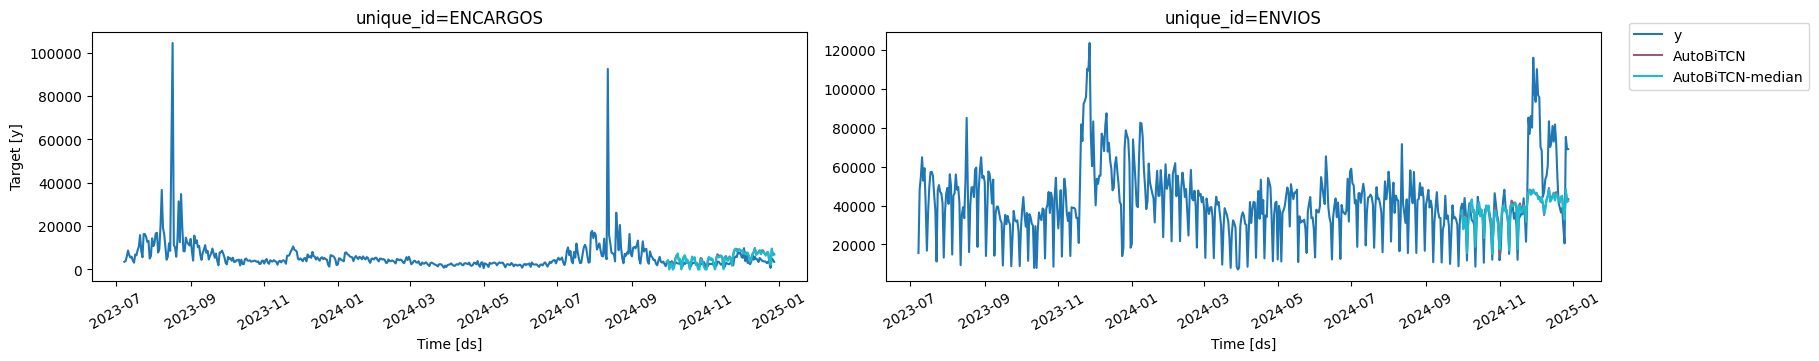

In [31]:
plot_series(train_data, Y_hat_df, max_insample_length=horizon*5)


In [53]:
# df_fore.to_csv(f'RESULTADOS_TOTD.csv', index=False)

In [42]:
df_fore

,LABEL,FECHA,Y,DT_REF,SESSION_TAG,FUTURE,VARIANT,YHATFIN
0,PRIME_COMPLEMENTOS,2024-09-30,855,2024-09-29,Auto_Prime_v1,1,AutoBiTCN,543.409973
1,PRIME_COMPLEMENTOS,2024-10-01,367,2024-09-29,Auto_Prime_v1,1,AutoBiTCN,273.639008
2,PRIME_COMPLEMENTOS,2024-10-02,548,2024-09-29,Auto_Prime_v1,1,AutoBiTCN,459.372009
3,PRIME_COMPLEMENTOS,2024-10-03,558,2024-09-29,Auto_Prime_v1,1,AutoBiTCN,431.152008
4,PRIME_COMPLEMENTOS,2024-10-04,254,2024-09-29,Auto_Prime_v1,1,AutoBiTCN,329.092010
...,...,...,...,...,...,...,...,...
625,PRIME_ZAPATERÍA,2024-12-24,107,2024-09-29,Auto_Prime_v1,1,AutoBiTCN,421.623993
626,PRIME_ZAPATERÍA,2024-12-25,134,2024-09-29,Auto_Prime_v1,1,AutoBiTCN,622.177979
627,PRIME_ZAPATERÍA,2024-12-26,2454,2024-09-29,Auto_Prime_v1,1,AutoBiTCN,2265.179932
628,PRIME_ZAPATERÍA,2024-12-27,428,2024-09-29,Auto_Prime_v1,1,AutoBiTCN,445.157990


In [43]:
from snowflake.snowpark.functions import col, to_date, to_char

# Crear el DataFrame de Snowpark a partir del DataFrame de pandas
snowpark_df = sess.create_dataframe(df_fore)
snowpark_df = snowpark_df.with_column("FECHA", to_date(col("FECHA")))
snowpark_df = snowpark_df.with_column("DT_REF", to_char(col("DT_REF"), 'YYYY-MM-DD'))



# Lista de columnas que espera la tabla destino
columnas_tabla = [
    "LEVEL", "KEY", "DT_REF", "SESSION_TAG", "ESTIMATOR", "VARIANT",
    "LABEL", "LABEL_N0", "LABEL_N1", "LABEL_N2", "LABEL_N3",
    "LABEL_N4", "LABEL_N5", "LABEL_N6", "LABEL_N7", "KV", "STEP",
    "FUTURE", "FECHA", "Y", "YHAT", "YHAT1", "YHAT2", "YHAT3", "YHAT4",
    "YHAT5", "YHAT6", "YHAT7", "YHAT8", "YHATFIN", "YHAT_L", "YHAT_U",
    "SLOT_0", "SLOT_1", "SLOT_2", "SLOT_3", "SLOT_4", "SLOT_5", "SLOT_6",
    "SLOT_7", "SLOT_8", "SLOT_9", "SLOT_10", "SLOT_11", "SLOT_12",
    "SLOT_13", "SLOT_14", "SLOT_15", "SLOT_16", "SLOT_17", "SLOT_18",
    "SLOT_19", "SLOT_20", "SLOT_21", "SLOT_22", "SLOT_23", "SLOT_24",
    "DSLOT_TREND_0", "DSLOT_TREND_1", "NFO", "SET"
]

# Lista de columnas que tiene tu DataFrame de Snowpark (18 columnas)
columnas_existentes = snowpark_df.columns

# Agregar las columnas faltantes con un valor por defecto (None)
for col in set(columnas_tabla) - set(columnas_existentes):
    snowpark_df = snowpark_df.with_column(col, lit(None))

# Reordenar las columnas para que coincidan con el orden de la tabla destino
snowpark_df = snowpark_df.select(columnas_tabla)

# Reemplaza los valores NULL en las columnas específicas por "ALL"
snowpark_df = snowpark_df.na.fill({
    "LABEL_N0": "ALL",
    "LABEL_N4": "ALL",
    "LABEL_N5": "ALL",
    "LABEL_N6": "ALL",
    "LABEL_N7": "ALL"
})


snowpark_df.show()

------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
|"LEVEL"  |"KEY"  |"DT_REF"    |"SESSION_TAG"  |"ESTIMATOR"  |"VARIANT"  |"LABEL"             |"LABEL_N0"  |"LABEL_N1"  |"LABEL_N2"  |"LABEL_N3"  |"LABEL_N4"  |"LABEL_N5"  |"LABEL_N6"  |"LABEL_N7"  |"KV"  |"STEP"  |"FUTURE"  |"FECHA"     |"Y"   |"YHAT"  |"YHAT1"  |"YHAT2"  |"YHA

In [44]:
snowpark_df.write.mode("append").save_as_table("CAA_UAT.STG_FCDP.TB_DEMAND_PLANNING_FORECAST_JAQB_TEMP_DEV")

In [ ]:

# snowpark_df.write.save_as_table(table_name='FORECAST_REDES_JAQB',mode='overwrite')
# snowpark_df.write.mode("overwrite").save_as_table("esquema.tabla_destino")
# print("DataFrame cargado exitosamente en Snowflake usando Snowpark.")

DataFrame cargado exitosamente en Snowflake usando Snowpark.
